## Dataset Overview & Initial Exploration

**1- Load the data and Import libraries**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import pandas library for data manipulation and analysis
import pandas as pd

# Import NumPy library for numerical operations
import numpy as np

# Import Seaborn for advanced statistical visualizations built on top of Matplotlib
import seaborn as sns

# Import Matplotlib for basic plotting and data visualization
import matplotlib.pyplot as plt
%matplotlib inline
sns.set_theme()

**2- Analysis of AI Trust Insights data**

In [ ]:
# Load the AI Trust Insights dataset
df_original = pd.read_csv('/content/ai_skepticism_dataset.csv')

In [ ]:
df = df_original.copy()

**3- Inspect data using** *.head(), .info() and .describe()*

In [ ]:
# Display the first five records of the dataset
df.head()

,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,education_level,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,Claude,math_calculation,93.23,527,True,False,False,Moderate,45-54,Bachelors,...,Low,False,False,10.0,True,Google Search,10.7,80.15,True,Moderate Trust
1,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,PhD,...,NaN,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,High School,...,NaN,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,Professional,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,Masters,...,NaN,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust


In [ ]:
# Display dataset structure and column information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ai_model_name               1000 non-null   object 
 1   query_category              1000 non-null   object 
 2   ai_confidence_percentage    1000 non-null   float64
 3   response_character_count    1000 non-null   int64  
 4   has_cited_sources           1000 non-null   bool   
 5   contains_hedging_words      1000 non-null   bool   
 6   includes_disclaimer         1000 non-null   bool   
 7   answer_detail_level         1000 non-null   object 
 8   respondent_age_bracket      1000 non-null   object 
 9   education_level             1000 non-null   object 
 10  digital_literacy_score      1000 non-null   object 
 11  ai_familiarity_level        1000 non-null   object 
 12  decision_importance         1000 non-null   object 
 13  urgency_level               779 no

In [ ]:
# Generate summary statistics for numerical columns
df.describe()

,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,72.006790,429.022000,7.905000,14.840000,69.982020
std,14.663334,221.644937,1.766866,15.182336,18.176782
min,40.520000,50.000000,1.800000,0.000000,19.420000
25%,60.570000,239.500000,6.700000,0.000000,58.570000
50%,74.235000,423.000000,8.200000,11.050000,72.080000
75%,83.862500,629.000000,9.500000,28.200000,83.140000
max,98.660000,799.000000,10.000000,45.000000,100.000000


**4- Rename colunms** if needed

The column names are clear and well-defined

**5- Handle duplicates with panads**

In [ ]:
#Check number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


**6- Add a unique ID column**

In [ ]:
# Add a sequential ID column starting from 1
df['Model_id'] = range(1, len(df)+1)

# Move 'Model_id' to be the first column
df = df[['Model_id'] + [col for col in df.columns if col != 'Model_id']]

In [ ]:
# Preview first 5 rows
df.head()

,Model_id,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
0,1,Claude,math_calculation,93.23,527,True,False,False,Moderate,45-54,...,Low,False,False,10.0,True,Google Search,10.7,80.15,True,Moderate Trust
1,2,Llama,recipe_cooking,84.47,581,False,False,False,Specific,55-64,...,NaN,False,True,7.9,True,Asked Expert,44.3,92.33,True,Skeptical
2,3,Claude,general_knowledge,69.82,484,True,True,False,Very Specific,35-44,...,NaN,True,False,8.6,True,Consulted Documentation,37.5,67.32,True,Moderate Trust
3,4,Claude,creative_writing,79.61,73,True,True,False,Specific,45-54,...,NaN,NaN,False,8.9,True,Checked Official Source,22.7,73.12,True,Moderate Trust
4,5,Claude,creative_writing,67.71,146,False,True,False,Vague,55-64,...,NaN,True,True,9.0,True,Academic Paper,43.7,81.05,True,Moderate Trust


## Data Sampling & Summarization

**1- Handle Missing Value**

In [ ]:
# Check for missing values in each column
missing_values = df.isnull().sum()
print(missing_values)

Model_id                        0
ai_model_name                   0
query_category                  0
ai_confidence_percentage        0
response_character_count        0
has_cited_sources               0
contains_hedging_words          0
includes_disclaimer             0
answer_detail_level             0
respondent_age_bracket          0
education_level                 0
digital_literacy_score          0
ai_familiarity_level            0
decision_importance             0
urgency_level                 221
belief_alignment_status       342
subject_matter_expertise        0
trust_score_out_of_10           0
performed_fact_check            0
fact_check_method_used        372
verification_duration_mins      0
answer_accuracy_percentage      0
trust_calibration_valid         0
user_skepticism_category        0
dtype: int64


In [ ]:
# Display the names of the column with missing values
# The columns with at least one missing value:
missing_values=missing_values[missing_values > 0]
missing_values

,0
urgency_level,221
belief_alignment_status,342
fact_check_method_used,372


**2-Data sampling with (random):**

In [ ]:
import random
random.seed(42)

In [ ]:
# Use random.sample() to select 10 random categories from unique query categories
query_categories= df['query_category'].unique()
random_categories= random.sample(list(query_categories),10)

print("Selected 10 random query categories:\n",random_categories)

NameError: name 'df' is not defined

**3- Extract rows**

In [ ]:
data_sample=df[df['query_category'].isin(random_categories)]
print("The length of the resulting sample data:\n",len(data_sample))

The length of the resulting sample data:
 846


In [ ]:
# Show counts for each category in the sample data
print("Counts per query category in the sample:\n")
print(data_sample['query_category'].value_counts())

Counts per query category in the sample:

query_category
recipe_cooking        101
scientific_facts       96
math_calculation       92
opinion_based          87
medical_advice         84
technical_coding       83
general_knowledge      82
legal_advice           81
factual_historical     77
creative_writing       63
Name: count, dtype: int64


**4- Data Summerization**

In [ ]:
# Number of unique query categories in the sample
num_categories=data_sample['query_category'].nunique()
print("Number of unique query categories:",num_categories)

Number of unique query categories: 10


In [ ]:
# Number of unique AI models in the sample
num_models=data_sample['ai_model_name'].nunique()
print("Number of unique AI models:",num_models)

Number of unique AI models: 6


In [ ]:
# Count & display all rows
model_count=data_sample['ai_model_name'].value_counts()
print("AI model counts in the sample:\n")
print(model_count)

AI model counts in the sample:

ai_model_name
Gemini         161
Llama          145
Claude         142
ChatGPT-3.5    141
Mistral        129
GPT-4          128
Name: count, dtype: int64


**5-Using groupby():**

In [ ]:
#For each AI model compute average trust score
model_trust=data_sample.groupby('ai_model_name')['trust_score_out_of_10'].mean().reset_index(name='avg_trust')

print("Average trust score per AI model: \n")
print(model_trust)

Average trust score per AI model: 

  ai_model_name  avg_trust
0   ChatGPT-3.5   7.890780
1        Claude   8.408451
2         GPT-4   8.314844
3        Gemini   8.014907
4         Llama   7.833793
5       Mistral   8.216279


**summray statistics: **

In [ ]:
# Compute summary statistics for avg_trust
trust_stats=model_trust['avg_trust'].describe()
print("Summary statistics for avg_trust column:\n")
print(trust_stats)

Summary statistics for avg_trust column:

count    6.000000
mean     8.113176
std      0.234802
min      7.833793
25%      7.921812
50%      8.115593
75%      8.290203
max      8.408451
Name: avg_trust, dtype: float64


**6-using pivot_table():**

In [ ]:
trust_pivot = pd.pivot_table(
    data_sample,
    values='trust_score_out_of_10',
    index='ai_model_name',
    columns='query_category',
    aggfunc= 'mean'
).reset_index()

print("Average trust score per model(pivoot table)\n")
print(trust_pivot)

Average trust score per model(pivoot table)

query_category ai_model_name  creative_writing  factual_historical  \
0                ChatGPT-3.5          8.527273            8.680000   
1                     Claude          8.400000            8.718182   
2                      GPT-4          8.957143            9.143750   
3                     Gemini          7.600000            8.821429   
4                      Llama          7.633333            8.568750   
5                    Mistral          7.116667            8.620000   

query_category  general_knowledge  legal_advice  math_calculation  \
0                        7.723529      6.457143          9.180000   
1                        8.425000      7.081818          9.280000   
2                        8.527273      6.736364          9.540000   
3                        8.570000      6.521053          9.772727   
4                        8.492308      6.826667          9.526667   
5                        8.066667      6.854545   

**7- Data Visualization**

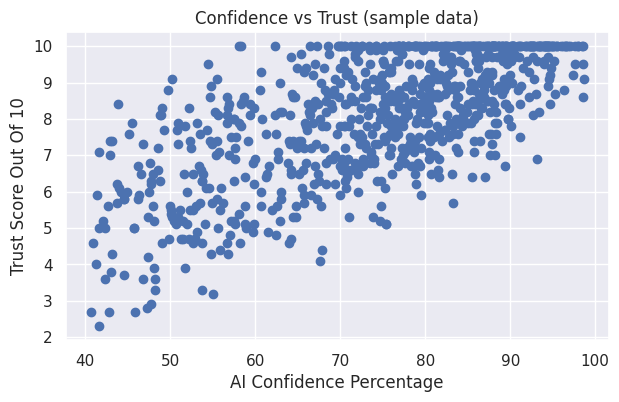

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.scatter(data_sample['ai_confidence_percentage'],
            data_sample['trust_score_out_of_10'])
plt.title("Confidence vs Trust (sample data)")
plt.xlabel("AI Confidence Percentage")
plt.ylabel("Trust Score Out Of 10")
plt.show()

## Missing Value Handling

**1- Handle missing values**

In [ ]:
# Checking missing values in each column
missing_values = df.isnull().sum()
missing_values= missing_values[missing_values >0]
print("Columns with missing values:\n")
print(missing_values)

Columns with missing values:

urgency_level              221
belief_alignment_status    342
fact_check_method_used     372
dtype: int64


A) Nmeric Column (median)
*   Will not be applied because the missing values aren't in numerical colunm




B) Categorical Columns (unknown)

In [ ]:
# Fill with "Unknown"
categorical_cols = ['urgency_level',
                    'belief_alignment_status',
                    'fact_check_method_used']

for col in categorical_cols:
  df[col].fillna("Unknown", inplace=True)   # instead of "Unknown" we can put "No fact check"

/tmp/ipykernel_11015/3149444022.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna("Unknown", inplace=True)   # instead of "Unknown" we can put "No fact check"


In [ ]:
# Checking
print("Remaining missing values: ")
print(df.isnull().sum())

Remaining missing values: 
Model_id                      0
ai_model_name                 0
query_category                0
ai_confidence_percentage      0
response_character_count      0
has_cited_sources             0
contains_hedging_words        0
includes_disclaimer           0
answer_detail_level           0
respondent_age_bracket        0
education_level               0
digital_literacy_score        0
ai_familiarity_level          0
decision_importance           0
urgency_level                 0
belief_alignment_status       0
subject_matter_expertise      0
trust_score_out_of_10         0
performed_fact_check          0
fact_check_method_used        0
verification_duration_mins    0
answer_accuracy_percentage    0
trust_calibration_valid       0
user_skepticism_category      0
dtype: int64


C) Sequential Fill
*  Will not be applied because the dataset has no time/sequence order.
*  May creat incorrect values



**2- Drop missing value** (if there's any)

In [ ]:
df.isnull().values.any()

np.False_

**3- Advanced method**

In [ ]:
from sklearn.impute import SimpleImputer

#select numeric columns
numeric_cols =df.select_dtypes(include=['float64' , 'int64']).columns

#creat imputer using mean strategy
imputer = SimpleImputer(strategy='mean')

#apply imputation on numeric columns
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

#check remaining missing values in numeric columns
print("Remainig missing values in numeric columns:\n")
print(df[numeric_cols].isnull().sum())

Remainig missing values in numeric columns:

Model_id                      0
ai_confidence_percentage      0
response_character_count      0
trust_score_out_of_10         0
verification_duration_mins    0
answer_accuracy_percentage    0
dtype: int64


## Outlier Detection & Treatment

**1- Detect outliers visually using Boxplot**

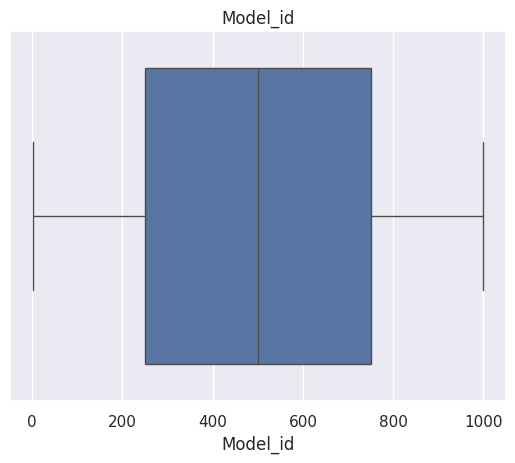

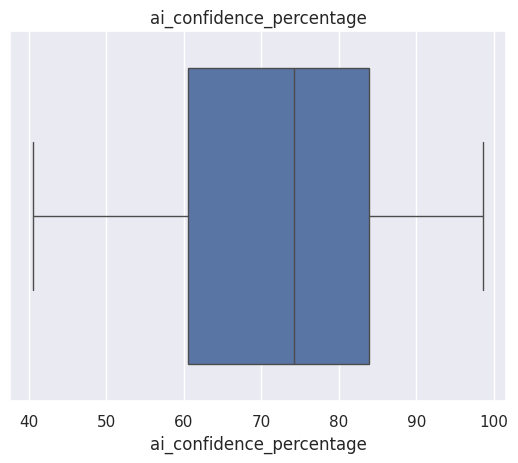

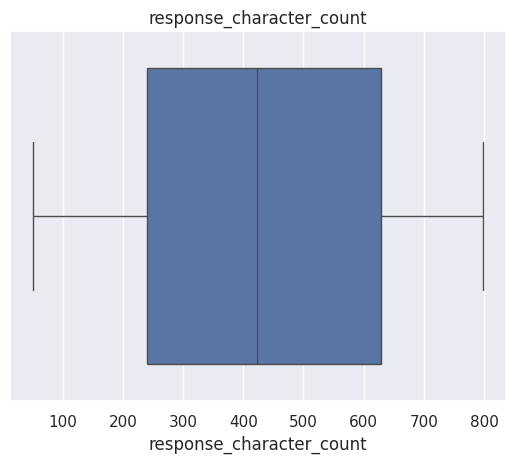

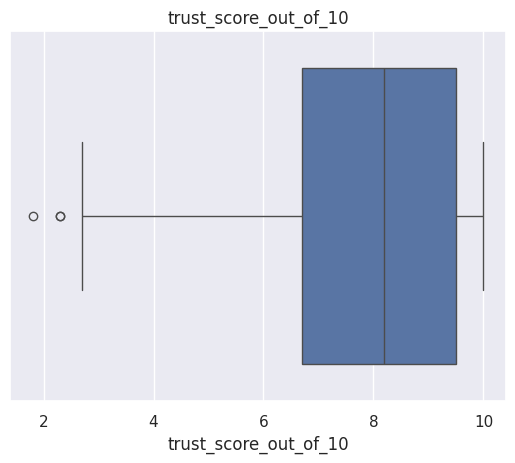

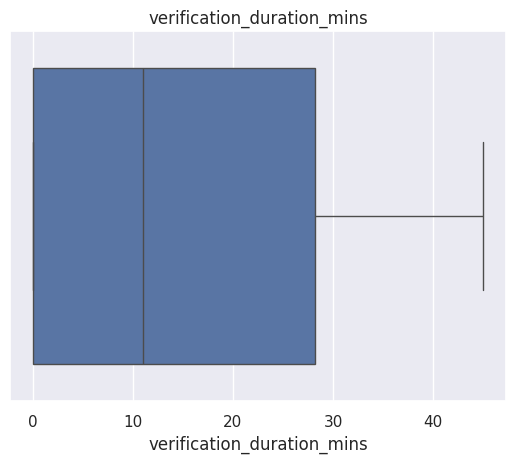

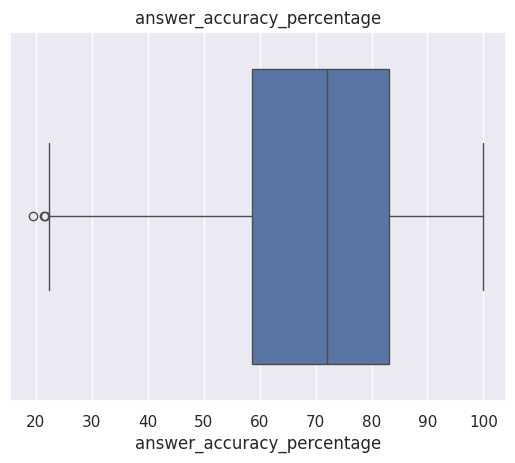

In [ ]:
for col in df.select_dtypes(include='number').columns:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**2- Detect outliers using IQR rule**

In [ ]:
# IQR rule
Q1 = df['trust_score_out_of_10'].quantile(0.25)
Q3 = df['trust_score_out_of_10'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df_outliers = df[(df['trust_score_out_of_10'] < lower) |
(df['trust_score_out_of_10'] > upper)]
df_outliers

,Model_id,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
218,219.0,ChatGPT-3.5,opinion_based,41.66,782.0,False,False,False,Vague,45-54,...,Low,False,False,2.3,True,Academic Paper,34.3,24.18,True,Highly Skeptical
299,300.0,Gemini,financial_advice,44.99,405.0,False,True,True,Vague,65+,...,Low,False,True,1.8,True,Google Search,32.7,42.14,False,Highly Skeptical
743,744.0,Gemini,financial_advice,48.41,798.0,False,True,True,Vague,55-64,...,Medium,False,False,2.3,True,Asked Expert,17.9,51.08,False,Highly Skeptical


In [ ]:
# IQR rule
Q1 = df['answer_accuracy_percentage'].quantile(0.25)
Q3 = df['answer_accuracy_percentage'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
df_outliers = df[(df['answer_accuracy_percentage'] < lower) |
(df['answer_accuracy_percentage'] > upper)]
df_outliers

,Model_id,ai_model_name,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,answer_detail_level,respondent_age_bracket,...,urgency_level,belief_alignment_status,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,fact_check_method_used,verification_duration_mins,answer_accuracy_percentage,trust_calibration_valid,user_skepticism_category
23,24.0,Llama,opinion_based,42.81,86.0,True,False,True,Very Specific,45-54,...,High,False,False,2.7,True,Academic Paper,2.5,21.40,True,Highly Skeptical
507,508.0,GPT-4,opinion_based,40.66,797.0,False,True,True,Vague,25-34,...,Low,False,True,2.7,True,Personal Testing,36.7,21.70,True,Highly Skeptical
894,895.0,Llama,opinion_based,41.36,525.0,True,False,False,Specific,25-34,...,Unknown,Unknown,False,5.9,True,Asked Colleague,22.4,19.42,False,Skeptical


**3- handle outliers**

In [ ]:

df.loc[(df['answer_accuracy_percentage']<lower) | (df['trust_score_out_of_10']> upper), 'trust_score_out_of_10']=np.nan

In [ ]:
df['answer_accuracy_percentage'].fillna(df['trust_score_out_of_10'].median(), inplace=True)

/tmp/ipykernel_11015/3495835222.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['answer_accuracy_percentage'].fillna(df['trust_score_out_of_10'].median(), inplace=True)


Outlier Handling Explanation

Outliers were detected using boxplot visualization and the IQR rule. After inspecting the extreme values, they appeared to be plausible and within realistic ranges rather than data entry errors. Therefore, instead of removing them, the outliers were replaced with missing values and then imputed using the median. This approach helps reduce the impact of extreme values on the analysis while preserving the overall structure of the dataset.

## Feature Scaling & Encoding

1- Check data distribution for Normalization

In [ ]:
# Numeric column
print(df.select_dtypes(include='number').columns.tolist())

['Model_id', 'ai_confidence_percentage', 'response_character_count', 'trust_score_out_of_10', 'verification_duration_mins', 'answer_accuracy_percentage']


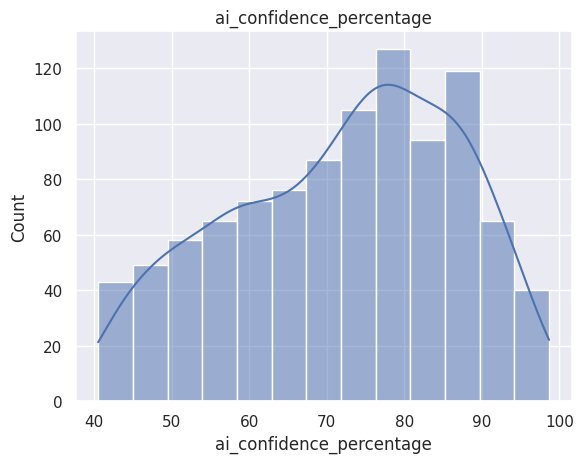

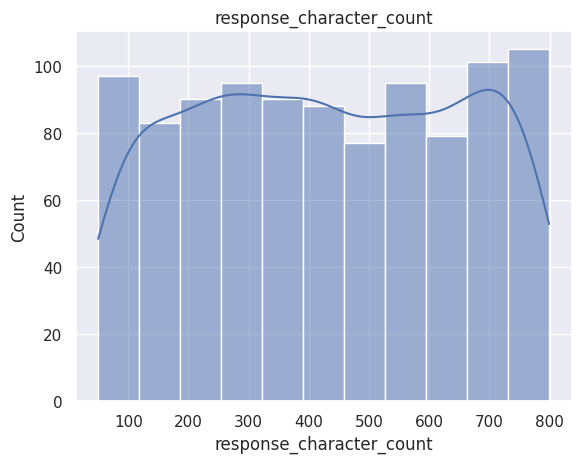

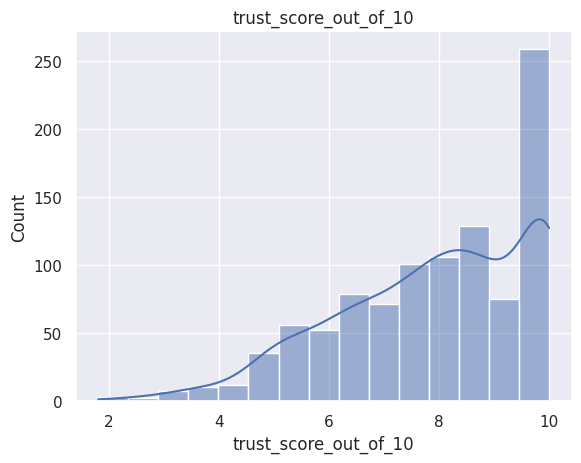

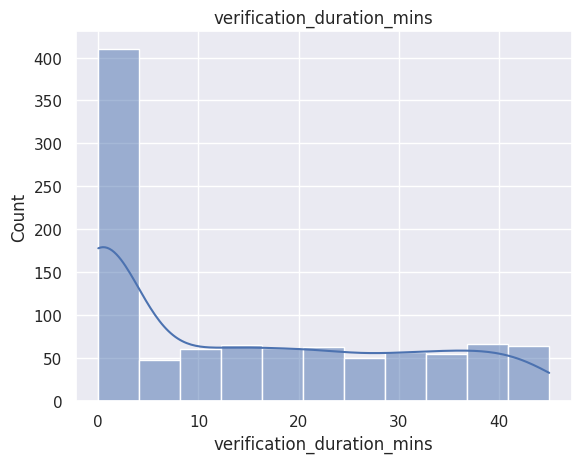

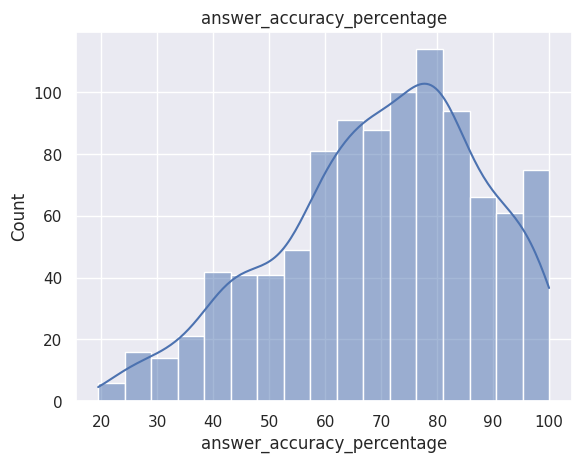

In [ ]:
cols = ['ai_confidence_percentage', 'response_character_count',
        'trust_score_out_of_10', 'verification_duration_mins',
        'answer_accuracy_percentage']

for col in cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
for col in cols:
    print(f"{col}: skew={df[col].skew():.2f}")

ai_confidence_percentage: skew=-0.31
response_character_count: skew=-0.01
trust_score_out_of_10: skew=-0.65
verification_duration_mins: skew=0.53
answer_accuracy_percentage: skew=-0.45


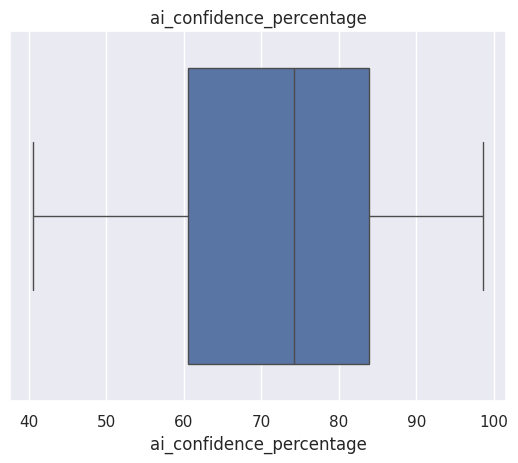

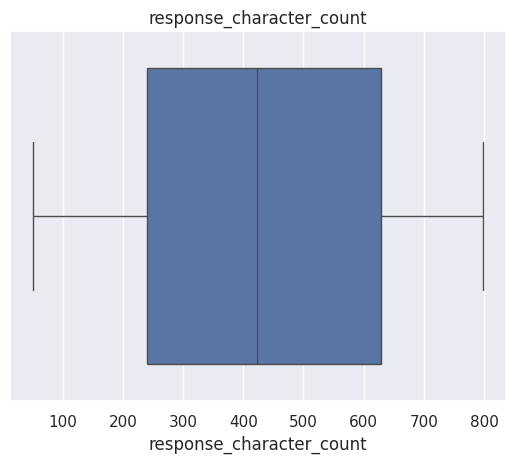

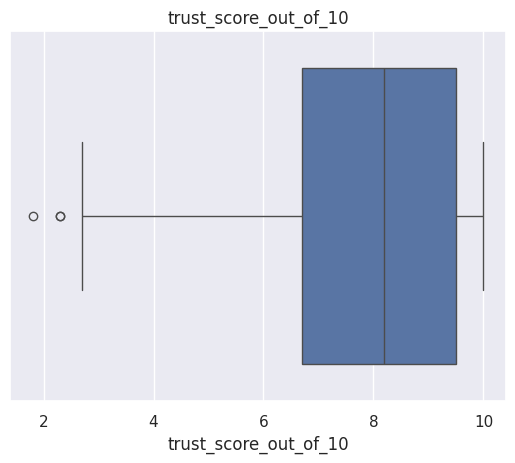

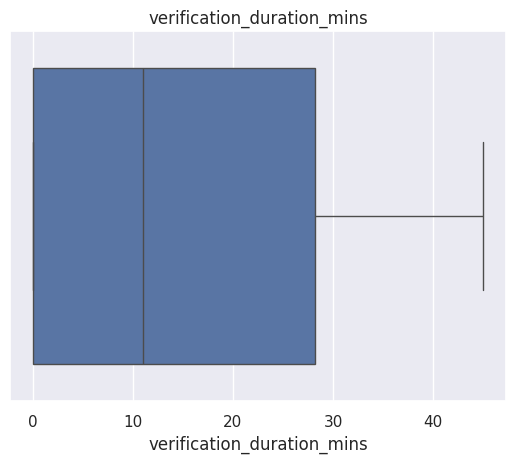

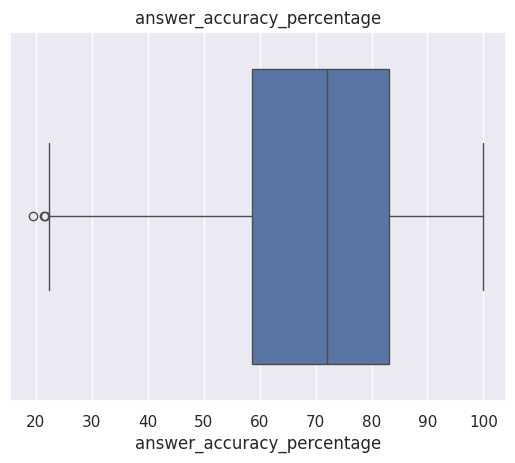

In [ ]:
# Box plot to check Outliers
for col in cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

**Numeric columns**

In [ ]:
#Min/Max Normalization
from sklearn.preprocessing import MinMaxScaler

numeric_df = df.select_dtypes(include=['number'])

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
scaled_df.head()

,Model_id,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
0,0.000000,0.906605,0.636849,1.000000,0.237778,0.753661
1,0.001001,0.755934,0.708945,0.743902,0.984444,0.904815
2,0.002002,0.503956,0.579439,0.829268,0.833333,0.594440
3,0.003003,0.672343,0.030708,0.865854,0.504444,0.666418
4,0.004004,0.467664,0.128171,0.878049,0.971111,0.764830


In [ ]:
#Robust Scaler
from sklearn.preprocessing import RobustScaler

numeric_df = df.select_dtypes(include=['number'])

scaler = RobustScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
scaled_df.head()

,Model_id,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
0,-1.000000,0.815499,0.267009,0.642857,-0.012411,0.328449
1,-0.997998,0.439412,0.405648,-0.107143,1.179078,0.824176
2,-0.995996,-0.189546,0.156611,0.142857,0.937943,-0.193732
3,-0.993994,0.230761,-0.898588,0.250000,0.413121,0.042328
4,-0.991992,-0.280133,-0.711168,0.285714,1.157801,0.365079


**Categorical column**

In [ ]:
# n>10 (Binary Encoding)
# n<=10 (One-Hot Encoding)
# n=2 (Label Encoding)
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    n = df[col].nunique()
    print(f"{col}:{n}")


ai_model_name:6
query_category:12
answer_detail_level:4
respondent_age_bracket:6
education_level:5
digital_literacy_score:4
ai_familiarity_level:5
decision_importance:4
urgency_level:4
belief_alignment_status:3
fact_check_method_used:9
user_skepticism_category:4


In [ ]:
df_onehot = pd.get_dummies(
    df, columns=[
        'ai_model_name',
        'answer_detail_level',
        'respondent_age_bracket',
        'education_level',
        'digital_literacy_score',
        'ai_familiarity_level',
        'decision_importance',
        'urgency_level',
        'belief_alignment_status',
        'fact_check_method_used',
        'user_skepticism_category'])
df_onehot = df_onehot * 1
df_onehot.head()

,Model_id,query_category,ai_confidence_percentage,response_character_count,has_cited_sources,contains_hedging_words,includes_disclaimer,subject_matter_expertise,trust_score_out_of_10,performed_fact_check,...,fact_check_method_used_Checked Official Source,fact_check_method_used_Consulted Documentation,fact_check_method_used_Cross-referenced Multiple AIs,fact_check_method_used_Google Search,fact_check_method_used_Personal Testing,fact_check_method_used_Unknown,user_skepticism_category_Blind Trust,user_skepticism_category_Highly Skeptical,user_skepticism_category_Moderate Trust,user_skepticism_category_Skeptical
0,1.0,math_calculation,93.23,527.0,1,0,0,0,10.0,1,...,0,0,0,1,0,0,0,0,1,0
1,2.0,recipe_cooking,84.47,581.0,0,0,0,1,7.9,1,...,0,0,0,0,0,0,0,0,0,1
2,3.0,general_knowledge,69.82,484.0,1,1,0,0,8.6,1,...,0,1,0,0,0,0,0,0,1,0
3,4.0,creative_writing,79.61,73.0,1,1,0,0,8.9,1,...,1,0,0,0,0,0,0,0,1,0
4,5.0,creative_writing,67.71,146.0,0,1,0,1,9.0,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# The .dropna(subset=['belief_alignment_status']) was removed because missing values
# were handled in a previous cell by filling them with 'Unknown'.

# Convert boolean values to strings before encoding
df['belief_alignment_status'] = df['belief_alignment_status'].astype(str)

le = LabelEncoder()
df['belief_alignment_status'] = le.fit_transform(df['belief_alignment_status'])

print(df[['belief_alignment_status']].head())
print("unique values:", df['belief_alignment_status'].unique())

   belief_alignment_status
0                        0
1                        0
2                        1
3                        2
4                        1
unique values: [0 1 2]


## Feature Selection & Dimensionality Reduction

In [ ]:
df_fe = df.copy()

**1-Featue selection**

Filter method(correlation)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
corr = df_fe.copy()
corr = corr.select_dtypes(include=['number'])
corr_matrix=corr.corr()

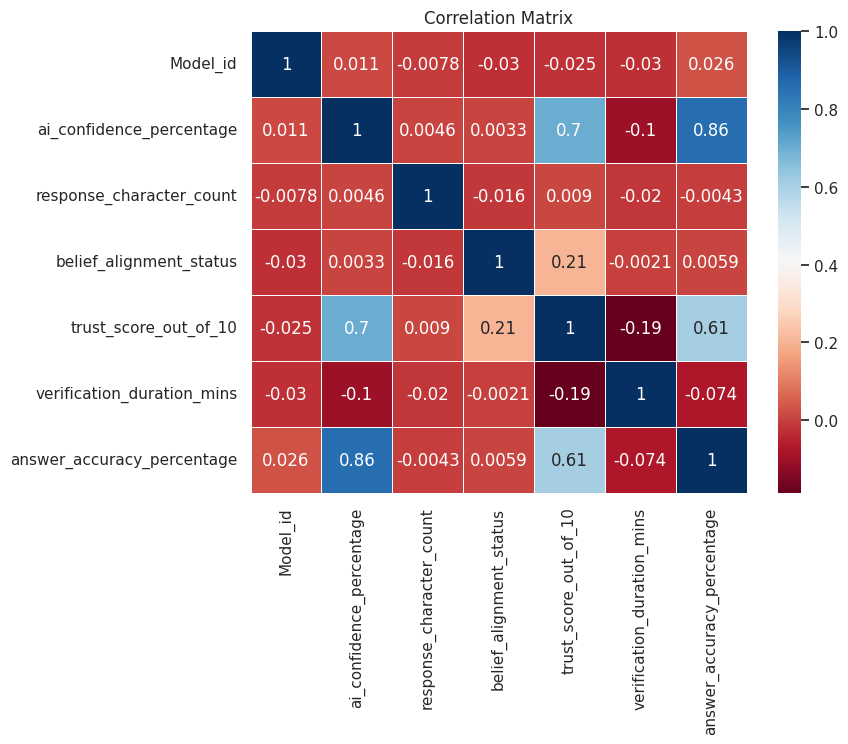

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True, cmap="RdBu", linewidth=0.5)
plt.title("Correlation Matrix")
plt.show()

## Correlation Analysis Summary

From the correlation matrix:

* Strong positive relationships were observed between:

  * **ai_confidence_percentage and answer_accuracy_percentage (0.86)** indicating a very strong correlation.
  * **ai_confidence_percentage and trust_score_out_of_10 (0.66)** showing a strong relationship.
  * **trust_score_out_of_10 and answer_accuracy_percentage (0.59)** indicating a moderate to strong correlation.
  * **belief_alignment_status and trust_score_out_of_10 (0.56)** showing a moderate correlation.

* Weak or negligible relationships were observed for:

  * **response_character_count**, which shows very low correlation with all other features.
  * **verification_duration_mins**, which also has weak or negative correlations with most variables.

Wrapper method(RFE)

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Impute NaN values in 'trust_score_out_of_10' which were introduced during outlier handling
# This ensures that the input to LinearRegression is free of missing values
if df_fe['trust_score_out_of_10'].isnull().any():
    median_trust_score = df_fe['trust_score_out_of_10'].median()
    df_fe['trust_score_out_of_10'].fillna(median_trust_score, inplace=True)

x = df_fe.select_dtypes(include=['number']).drop('answer_accuracy_percentage', axis=1)
y = df_fe['answer_accuracy_percentage']

model = LinearRegression()
rfe = RFE(model, n_features_to_select= 3)

x_selected = rfe.fit_transform(x, y)

print(rfe.support_)
print(x.columns[rfe.support_])

[False  True False  True  True False]
Index(['ai_confidence_percentage', 'belief_alignment_status',
       'trust_score_out_of_10'],
      dtype='object')


/tmp/ipykernel_11015/2997599721.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_fe['trust_score_out_of_10'].fillna(median_trust_score, inplace=True)


The target is 'answer_accuracy_percentage' because it represents the final outcome (how accurate the AI's answer is).

Feature Extraction(PCA)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [ ]:
#scaling
numeric_df_fe = df_fe.select_dtypes(include=['number'])

scaler = RobustScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)
scaled_df.head()

,Model_id,ai_confidence_percentage,response_character_count,trust_score_out_of_10,verification_duration_mins,answer_accuracy_percentage
0,-1.000000,0.815499,0.267009,0.642857,-0.012411,0.328449
1,-0.997998,0.439412,0.405648,-0.107143,1.179078,0.824176
2,-0.995996,-0.189546,0.156611,0.142857,0.937943,-0.193732
3,-0.993994,0.230761,-0.898588,0.250000,0.413121,0.042328
4,-0.991992,-0.280133,-0.711168,0.285714,1.157801,0.365079


In [ ]:
pca = PCA()
X_pca = pca.fit_transform(numeric_df_fe) #scaled

In [ ]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print(explained_variance)
print(cumulative_variance)

[6.25733092e-01 3.68423454e-01 3.84437292e-03 1.70429704e-03
 2.78360907e-04 1.20996139e-05 4.32283769e-06]
[0.62573309 0.99415655 0.99800092 0.99970522 0.99998358 0.99999568
 1.        ]


Text(0.5, 1.0, 'Explained Variance vs Components')

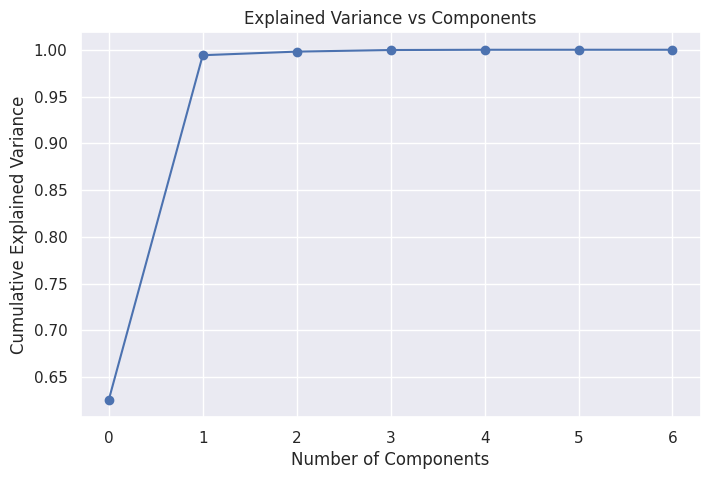

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Components')

Apply PCA with 2 component

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(numeric_df_fe)

print(pca.explained_variance_ratio_)

[0.62573309 0.36842345]


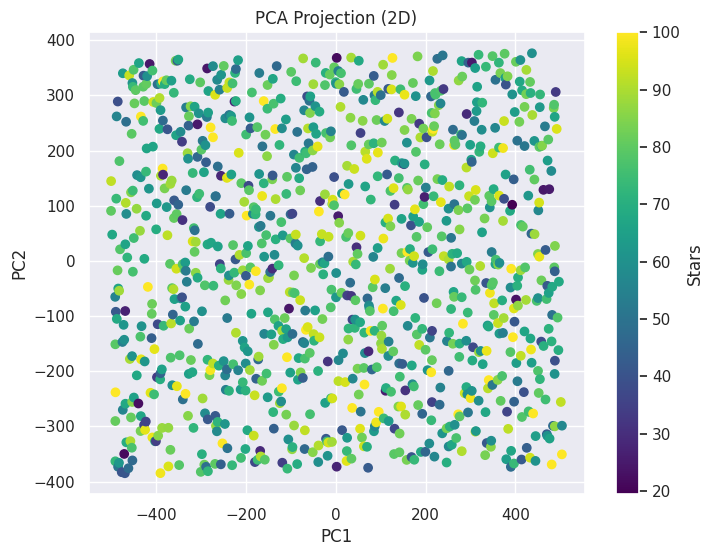

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (2D)')
plt.colorbar(label='Stars')
plt.show()

# Data Reshaping & Tidy Data

In [ ]:
df_fe = df.copy()

**1- Pivoting data** (long to wide)

In [ ]:
pivot_df = pd.pivot_table(
    df,
    values='trust_score_out_of_10',
    index='ai_model_name',
    columns='query_category',
    aggfunc='mean'
).round(2)
print(pivot_df)

query_category  creative_writing  current_events  factual_historical  \
ai_model_name                                                          
ChatGPT-3.5                 8.53            6.09                8.68   
Claude                      8.40            7.42                8.72   
GPT-4                       8.96            7.74                9.14   
Gemini                      7.60            7.58                8.82   
Llama                       7.63            7.74                8.57   
Mistral                     7.12            8.08                8.62   

query_category  financial_advice  general_knowledge  legal_advice  \
ai_model_name                                                       
ChatGPT-3.5                 5.77               7.72          6.46   
Claude                      6.53               8.42          7.08   
GPT-4                       6.75               8.53          6.74   
Gemini                      5.82               8.57          6.52   
Llama    

In [ ]:
pivot_df.head()

query_category,creative_writing,current_events,factual_historical,financial_advice,general_knowledge,legal_advice,math_calculation,medical_advice,opinion_based,recipe_cooking,scientific_facts,technical_coding
ai_model_name,,,,,,,,,,,,
ChatGPT-3.5,8.53,6.09,8.68,5.77,7.72,6.46,9.18,6.91,5.84,8.48,8.72,8.86
Claude,8.40,7.42,8.72,6.53,8.42,7.08,9.28,7.61,6.05,9.23,9.18,9.23
GPT-4,8.96,7.74,9.14,6.75,8.53,6.74,9.54,7.77,6.13,8.59,8.65,8.97
Gemini,7.60,7.58,8.82,5.82,8.57,6.52,9.77,7.24,5.74,8.90,8.23,8.92
Llama,7.63,7.74,8.57,6.54,8.49,6.83,9.53,6.18,6.40,8.59,8.27,9.31


**2- Melting data** (wide to long)

In [ ]:
# Melt converts columns into rows

id_col = df.columns[0]

value_cols = df.select_dtypes(include=np.number).columns.tolist()

melted_df = pd.melt(
    df,
    id_vars=[id_col],
    value_vars=value_cols,
    var_name="Question_or_Feature",
    value_name="Value")

melted_df.head()

,Model_id,Question_or_Feature,Value
0,1.0,ai_confidence_percentage,93.23
1,2.0,ai_confidence_percentage,84.47
2,3.0,ai_confidence_percentage,69.82
3,4.0,ai_confidence_percentage,79.61
4,5.0,ai_confidence_percentage,67.71


**3- Stack & unstack**

In [ ]:
stacked = pivot_df.stack()
print(stacked)

ai_model_name  query_category    
ChatGPT-3.5    creative_writing      8.53
               current_events        6.09
               factual_historical    8.68
               financial_advice      5.77
               general_knowledge     7.72
                                     ... 
Mistral        medical_advice        6.96
               opinion_based         5.88
               recipe_cooking        8.77
               scientific_facts      8.56
               technical_coding      8.92
Length: 72, dtype: float64


In [ ]:
unstacked = stacked.unstack()
print(unstacked)

query_category  creative_writing  current_events  factual_historical  \
ai_model_name                                                          
ChatGPT-3.5                 8.53            6.09                8.68   
Claude                      8.40            7.42                8.72   
GPT-4                       8.96            7.74                9.14   
Gemini                      7.60            7.58                8.82   
Llama                       7.63            7.74                8.57   
Mistral                     7.12            8.08                8.62   

query_category  financial_advice  general_knowledge  legal_advice  \
ai_model_name                                                       
ChatGPT-3.5                 5.77               7.72          6.46   
Claude                      6.53               8.42          7.08   
GPT-4                       6.75               8.53          6.74   
Gemini                      5.82               8.57          6.52   
Llama    

**4- Crosstab**

In [ ]:
df = pd.read_csv('ai_skepticism_dataset.csv')

print(df)

ct = pd.crosstab(df['ai_model_name'], df['answer_detail_level'])
print(ct)

    ai_model_name     query_category  ai_confidence_percentage  \
0          Claude   math_calculation                     93.23   
1           Llama     recipe_cooking                     84.47   
2          Claude  general_knowledge                     69.82   
3          Claude   creative_writing                     79.61   
4          Claude   creative_writing                     67.71   
..            ...                ...                       ...   
995        Gemini   math_calculation                     94.09   
996         Llama   financial_advice                     62.60   
997        Claude   technical_coding                     77.38   
998   ChatGPT-3.5   math_calculation                     98.61   
999         Llama      opinion_based                     55.61   

     response_character_count  has_cited_sources  contains_hedging_words  \
0                         527               True                   False   
1                         581              False       

**5- Cut function**

In [ ]:
import pandas as pd

df = pd.read_csv('ai_skepticism_dataset.csv')

pivot_df = pd.pivot_table(
    df,
    values='trust_score_out_of_10',
    index='ai_model_name',
    columns='query_category',
    aggfunc='mean').round(2)

pivot_df['creative_level'] = pd.cut(
    pivot_df['creative_writing'],
    bins=[0, 7, 8.5, 10],
    labels=['Low', 'Medium', 'High'])

pivot_df[['creative_writing', 'creative_level']].head()

query_category,creative_writing,creative_level
ai_model_name,,
ChatGPT-3.5,8.53,High
Claude,8.40,Medium
GPT-4,8.96,High
Gemini,7.60,Medium
Llama,7.63,Medium


**6- Explode function**

In [ ]:
df['fact_check_method_used'].apply(type).value_counts()

,count
fact_check_method_used,
<class 'str'>,628
<class 'float'>,372


In [ ]:
df['fact_check_method_used'].head(10)

,fact_check_method_used
0,Google Search
1,Asked Expert
2,Consulted Documentation
3,Checked Official Source
4,Academic Paper
5,NaN
6,NaN
7,NaN
8,Personal Testing
9,Cross-referenced Multiple AIs


One of the columns was examined and found to contain single text values ​​​​instead of list, Therefore the explode function is not applicable to this dataset.

**Tidy**

In [ ]:
# Final tidy data version using melt

tidy_df = melted_df.copy()

tidy_df.head()

# Save tidy dataset
tidy_df.to_csv("AI_Trust_Insights_Tidy.csv", index=False)

print("Tidy dataset saved successfully!")

Tidy dataset saved successfully!


###**Questions**

***Q1: What changes did you make to make the data tidy?***
We used cut() to bin ai_confidence_percentage into labeled categories, and explode() to expand list-like values into separate rows.


***Q2: Which reshaping method did you use, and why?***
We used pivot_table() to compare trust scores across models and categories, melt() to reverse it to long format and tidy the boolean columns, stack/unstack() to move column labels into the row index, and crosstab() to count occurrences per model and skepticism category

***Q3: What is the difference between wide and long format?***
Wide format (pivot_table): each row is one AI model, each column is one query category shape 6×12, easy to compare. Long format (melt): each row is one (model, category) pair shape 72×3, better for plotting and groupby.

# Text Preprocessing & NLP

**1- Importing libraries:**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize
from nltk.tokenize import word_tokenize
from collections import Counter
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

**2- Load new data:**

In [ ]:
df = pd.read_csv("/content/sentimentdataset.csv")

In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


**3- Select text:**

In [ ]:
sample_df = df.sample(n=100, random_state=42)

text = sample_df['Text']

print(text.shape)
print(text)

(100,)
604    Exploring the world of digital art. It's never...
33      Feeling inspired after attending a workshop. ...
300     Eyes wide open in the night, fearful shadows ...
457    A soul weathered by the storm of heartbreak, s...
634    Attended a wine tasting event, savoring the ri...
                             ...                        
456    Wandering in the maze of betrayal, the walls c...
254     Playfully dancing in the rain of laughter, a ...
368    Elation over discovering a rare book in a quai...
133     Fulfillment in completing a challenging worko...
174     Regret over missed opportunities haunts my th...
Name: Text, Length: 100, dtype: object


In [ ]:
# select one review
text = sample_df['Text'].iloc[0]
print(text)

Exploring the world of digital art. It's never too late to discover new passions. #DigitalArtistry #LateBloomer 


# **Text cleaning**

**4- Normalization:**

In [ ]:
text = sample_df['Text'].str.lower()
print(text)

604    exploring the world of digital art. it's never...
33      feeling inspired after attending a workshop. ...
300     eyes wide open in the night, fearful shadows ...
457    a soul weathered by the storm of heartbreak, s...
634    attended a wine tasting event, savoring the ri...
                             ...                        
456    wandering in the maze of betrayal, the walls c...
254     playfully dancing in the rain of laughter, a ...
368    elation over discovering a rare book in a quai...
133     fulfillment in completing a challenging worko...
174     regret over missed opportunities haunts my th...
Name: Text, Length: 100, dtype: object


**5- Remove punctuation:**

In [ ]:
text = text.str.replace('[^\w\s]', '', regex = True)
print(text)

604    exploring the world of digital art its never t...
33      feeling inspired after attending a workshop  ...
300     eyes wide open in the night fearful shadows d...
457    a soul weathered by the storm of heartbreak se...
634    attended a wine tasting event savoring the ric...
                             ...                        
456    wandering in the maze of betrayal the walls cl...
254     playfully dancing in the rain of laughter a w...
368    elation over discovering a rare book in a quai...
133     fulfillment in completing a challenging worko...
174     regret over missed opportunities haunts my th...
Name: Text, Length: 100, dtype: object


<>:1: SyntaxWarning: invalid escape sequence '\w'
<>:1: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_46379/2957845184.py:1: SyntaxWarning: invalid escape sequence '\w'
  text = text.str.replace('[^\w\s]', '', regex = True)


**6- Remove stopwords:**

In [ ]:
stop_words = set(stopwords.words('english'))
text

text = text.apply(lambda x: ' '.join([word for word in x.split() if word not in (stop_words)]))

print(text)

604    exploring world digital art never late discove...
33                   feeling inspired attending workshop
300    eyes wide open night fearful shadows dancing w...
457    soul weathered storm heartbreak seeking refuge...
634    attended wine tasting event savoring richness ...
                             ...                        
456    wandering maze betrayal walls closing every wr...
254    playfully dancing rain laughter whimsical spir...
368       elation discovering rare book quaint bookstore
133    fulfillment completing challenging workout rou...
174          regret missed opportunities haunts thoughts
Name: Text, Length: 100, dtype: object


# **Tokenization**

Tokenization : breaking text into smaller units.

**7- Word tokenization:**

In [ ]:
nltk.download('punkt_tab')

tokens = text.apply(word_tokenize)

print(tokens.head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


604    [exploring, the, world, of, digital, art, ., i...
33     [feeling, inspired, after, attending, a, works...
300    [eyes, wide, open, in, the, night, ,, fearful,...
457    [a, soul, weathered, by, the, storm, of, heart...
634    [attended, a, wine, tasting, event, ,, savorin...
Name: Text, dtype: object


**8- Sentence tokenization:**

In [ ]:
sentences = text.apply(sent_tokenize)

print(sentences.head())

604    [exploring the world of digital art., it's nev...
33       [ feeling inspired after attending a workshop.]
300    [ eyes wide open in the night, fearful shadows...
457    [a soul weathered by the storm of heartbreak, ...
634    [attended a wine tasting event, savoring the r...
Name: Text, dtype: object


# **Stemming & lemmatization**

**9- Stemming:**

Stemming : reduces words to thier roots, and can produce incorrect words.

In [ ]:
stemmer = PorterStemmer()

tokens_stemmed = tokens.apply(lambda x: [stemmer.stem(word) for word in x])

**10- Lemmatization:**

Lemmatization: better because it converts words into their correct dictionary form, preserving real meaning.

In [ ]:
lemmatizer = WordNetLemmatizer()

tokens_lemma = tokens.apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

print(tokens_lemma.head())

604    [exploring, the, world, of, digital, art, ., i...
33     [feeling, inspired, after, attending, a, works...
300    [eye, wide, open, in, the, night, ,, fearful, ...
457    [a, soul, weathered, by, the, storm, of, heart...
634    [attended, a, wine, tasting, event, ,, savorin...
Name: Text, dtype: object


**Most frequent words:**

In [ ]:
all_words =[]

for words in tokens_lemma:
    all_words.extend(words)

word_count = Counter(all_words)

common_words = word_count.most_common(10)

words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

common_words

[('.', 104),
 ('a', 102),
 ('the', 101),
 ('of', 79),
 (',', 62),
 ('in', 35),
 ('to', 20),
 ('#', 18),
 ('and', 18),
 ('with', 15)]

**Visualization:**

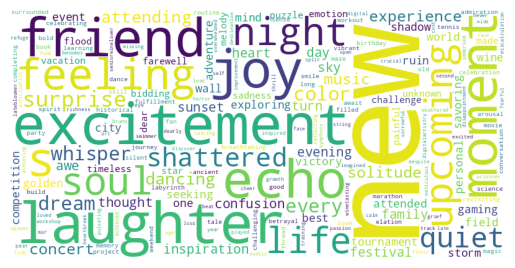

In [ ]:
text_all = " ".join(all_words)

wc = WordCloud(width=800, height=400, background_color='white').generate(text_all)

plt.imshow(wc)
plt.axis('off')
plt.show()